In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image
import matplotlib.pyplot as plt
import adom_library as adom
import adom_images as images

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


## Dropout

Ładowanie datasetu CIFAR-10

In [2]:
dataset = adom.get_CIFAR10_dataset()
classes = dataset.classes

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Trenowanie modeli

In [3]:
epochs = 5

print("With dropout 0.3:")
model_with_dropout_30 = adom.train_new_model(dataset, dropout_value=0.3, epochs=epochs)
print("With dropout 0.15:")
model_with_dropout_15 = adom.train_new_model(dataset, dropout_value=0.15, epochs=epochs)
print("Without dropout:")
model_without_dropout = adom.train_new_model(dataset, dropout_value=None, epochs=epochs)

With dropout 0.3:
Epoch 1, Loss: 1.3942, Acc: 48.99%
Epoch 2, Loss: 0.9279, Acc: 67.22%
Epoch 3, Loss: 0.7550, Acc: 73.61%
Epoch 4, Loss: 0.6390, Acc: 77.76%
Epoch 5, Loss: 0.5528, Acc: 80.56%
With dropout 0.15:
Epoch 1, Loss: 1.3798, Acc: 49.59%
Epoch 2, Loss: 0.9079, Acc: 67.96%
Epoch 3, Loss: 0.7364, Acc: 74.29%
Epoch 4, Loss: 0.6299, Acc: 78.16%
Epoch 5, Loss: 0.5440, Acc: 81.04%
Without dropout:
Epoch 1, Loss: 1.4245, Acc: 47.72%
Epoch 2, Loss: 0.9502, Acc: 66.45%
Epoch 3, Loss: 0.7381, Acc: 74.03%
Epoch 4, Loss: 0.6010, Acc: 79.13%
Epoch 5, Loss: 0.5003, Acc: 82.33%


Wyniki z droputem wynoszącym 0.3

Tiger:
frog 63.09 %
truck 11.92 %
bird 11.71 %
dog 4.62 %
cat 4.27 %

Horse:
horse 94.11 %
dog 3.21 %
deer 1.71 %
bird 0.53 %
cat 0.25 %


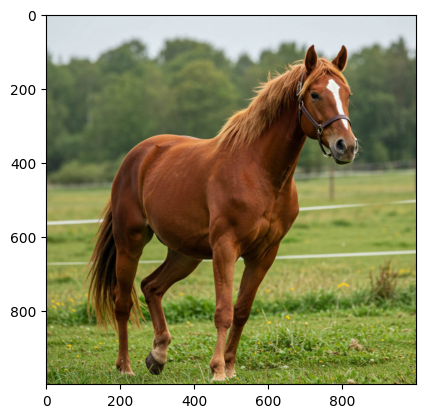

In [ ]:
print("Tiger:")
adom.classify_image_with_model(model=model_with_dropout_30, classes=classes)
print("\nHorse:")
adom.classify_image_with_model(model=model_with_dropout_30, classes=classes, image_path="external_images/kon.jpg")

Wyniki z droputem wynoszącym 0.15

Tiger:
truck 93.77 %
frog 5.73 %
cat 0.2 %
ship 0.16 %
dog 0.1 %

Horse:
horse 99.99 %
dog 0.0 %
deer 0.0 %
cat 0.0 %
bird 0.0 %


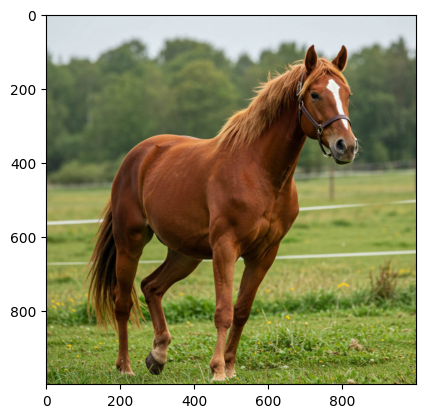

In [ ]:
print("Tiger:")
adom.classify_image_with_model(model=model_with_dropout_15, classes=classes)
print("\nHorse:")
adom.classify_image_with_model(model=model_with_dropout_15, classes=classes, image_path="external_images/kon.jpg")

Wyniki bez droputu

Tiger:
truck 98.55 %
cat 0.72 %
frog 0.32 %
dog 0.09 %
airplane 0.09 %

Horse:
horse 100.0 %
deer 0.0 %
dog 0.0 %
bird 0.0 %
cat 0.0 %


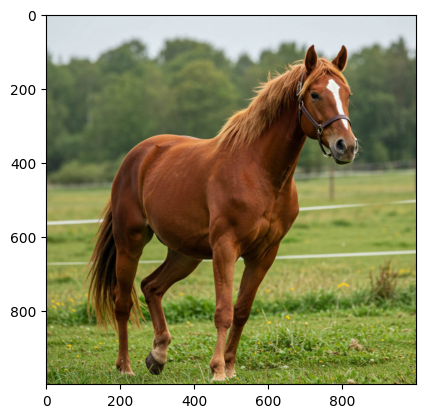

In [ ]:
print("Tiger:")
adom.classify_image_with_model(model=model_without_dropout, classes=classes)
print("\nHorse:")
adom.classify_image_with_model(model=model_without_dropout, classes=classes, image_path="external_images/kon.jpg")

## Pozyskiwanie obrazów testowych